Data Emas Perbulan
   hari     tanggal  harga_emas
0     1  2026-04-07     2834068
1     2  2026-04-08     2833165
2     3  2026-04-09     2832263
3     4  2026-04-10     2831361
4     5  2026-04-11     2830458
=== Evaluasi Model ===
MAE : 2117.960828775928
R2  : 0.9120673881600814

Prediksi Harga Emas Hari ke-(33): 2792937.024142991

Data Harga Emas dengan Z-Score:
    hari     tanggal  harga_emas   z_score
0      1  2026-04-07     2834068  1.097452
1      2  2026-04-08     2833165  1.024645
2      3  2026-04-09     2832263  0.951919
3      4  2026-04-10     2831361  0.879193
4      5  2026-04-11     2830458  0.806386
5      6  2026-04-12     2829556  0.733660
6      7  2026-04-13     2828654  0.660934
7      8  2026-04-14     2827752  0.588207
8      9  2026-04-15     2826850  0.515481
9     10  2026-04-16     2825947  0.442674
10    11  2026-04-17     2825045  0.369948
11    12  2026-04-18     2824143  0.297222
12    13  2026-04-19     2823240  0.224415
13    14  2026-04-20     2822

d:\Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


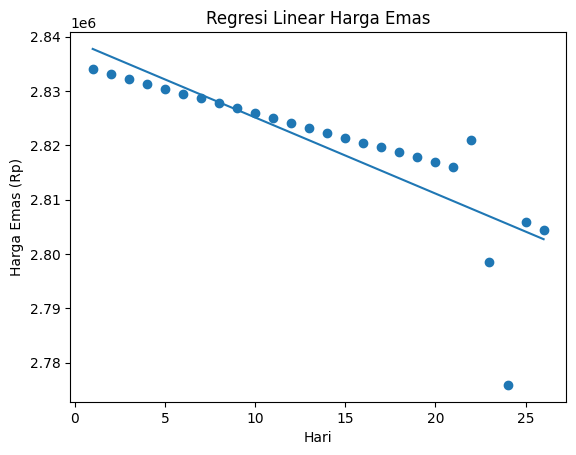

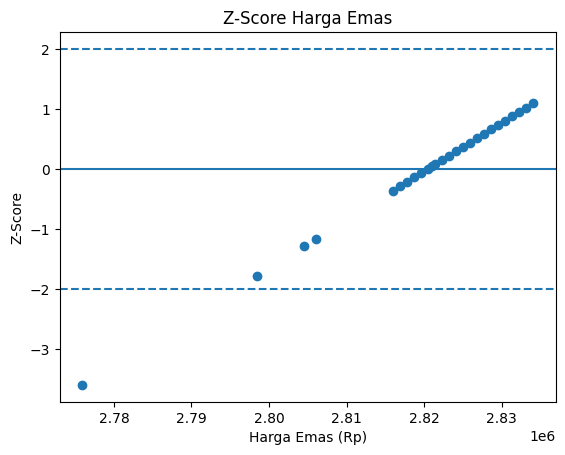

In [ ]:
# =========================================
# IMPORT LIBRARY
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from scipy.stats import zscore

# ==========================================
#Input Hari Setelah 33 Hari Terakhir (7 April 2026)
# ==========================================
hari = 33

# =========================================
# Dataset Emas Perbulan
# =========================================

df = pd.read_csv(r"D:\Code\Latihan Python\emas.csv")
print("Data Emas Perbulan")
print(df.head())

# =========================================
# Fitur Hari & Harga Emas
# =========================================
X = df[['hari']]
y = df['harga_emas']

#==========================================
# Split data (80% latihan, 20% tes)
#==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# Modeling (Linear Regression)
# =========================================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================================
# Prediksi
# =========================================
y_pred = model.predict(X_test)


# =========================================
# Evaluasi Model
# =========================================
print("=== Evaluasi Model ===")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

# =========================================
# Prediksi Data Baru
# =========================================
hari_baru = pd.DataFrame([hari])
prediksi = model.predict(hari_baru)

print("\nPrediksi Harga Emas Hari ke-({}):".format(hari), prediksi[0])

# =========================================
# Analisis Z-Score
# =========================================
df['z_score'] = zscore(df['harga_emas'])

print("\nData Harga Emas dengan Z-Score:")
print(df)

# =========================================
# Visualiasi Hasil 
# =========================================

# Grafik regresi linear
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Regresi Linear Harga Emas")
plt.xlabel("Hari")
plt.ylabel("Harga Emas (Rp)")
plt.show()

# Grafik Z-Score
plt.figure()
plt.scatter(df['harga_emas'], df['z_score'])

# Garis Batas 
plt.axhline(y=0)
plt.axhline(y=2, linestyle='--')
plt.axhline(y=-2, linestyle='--')

plt.title("Z-Score Harga Emas")
plt.xlabel("Harga Emas (Rp)")
plt.ylabel("Z-Score")
plt.show()